In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# CSV 불러오기
df = pd.read_csv("result/survey/survey_responses.csv")

likert_cols = [
        "dg1_clarity","dg2_prompt_to_image","dg2_image_to_prompt",
    "dg3_reusability","dg3_selective_edit","engagement","expressiveness",
    "exploration","effort_reward","transparency",

    "mental_demand","temporal_demand","effort","frustration","performance",
 ]

# engagement **
# effort vs reward *
# clear understanding of input-output ***

question_labels = {
    "mental_demand": "Mental Demand",
    "temporal_demand": "Temporal Demand",
    "performance": "Performance",
    "effort": "Effort",
    "frustration": "Frustration",
    "engagement": "Engagement **",
    "expressiveness": "Expressiveness *",
    "exploration": "Exploration *",
    "effort_reward": "Effort vs Reward *",
    "transparency": "Transparency",
    "dg1_clarity": "Clear representation of elements and relationships **",
    "dg2_prompt_to_image": "Clear understanding of input-output mapping ***",
    "dg2_image_to_prompt": "Easy identification of modifiable elements **",
    "dg3_reusability": "Ease of reuse and adaptation **",
    "dg3_selective_edit": "Ease of selective modification **"
}
# I was able to clearly represent all necessary elements and their relationships for this task.
# I could clearly understand which elements of my input corresponded to specific parts of the output.
# I could easily identify which input elements to modify when I wanted to change specific parts of the output.
# I found it easy to reuse or adapt my work for other similar tasks.
# I was able to selectively modify only the parts I wanted while keeping everything else unchanged.



plt.rcParams['font.family'] = 'AppleGothic'  # 한글 폰트 예시
plt.rcParams['font.size'] = 10

def plot_likert_responses(likert_cols, title="Likert Responses by System"):
    reverse_items = ["mental_demand", "temporal_demand", "effort", "frustration"]

    # long-format 변환
    likert_counts = df.melt(id_vars="system_type", value_vars=likert_cols, 
                            var_name="question", value_name="response")
    likert_counts["response"] = pd.to_numeric(likert_counts["response"], errors="coerce")

    # 각 system_type, question 별로 1~7 분포 비율 계산
    likert_counts = (
        likert_counts.groupby(["system_type","question","response"])
        .size().reset_index(name="count")
    )
    
    likert_counts["percent"] = likert_counts.groupby(["system_type","question"])["count"].transform(lambda x: x / x.sum() * 100)

    # 색상 팔레트 (1~7)
    colors = ["#8b0000","#cd5c5c","#f4cccc","#f2f2f2","#d9ead3","#6aa84f","#274e13"] # RdBu

    # 플롯
    fig, axes = plt.subplots(len(likert_cols), 1, figsize=(8, 1*len(likert_cols)), sharex=True)

    for i, q in enumerate(likert_cols):
        ax = axes[i]
        bottoms = {"Baseline": 0, "OOPT": 0}
        responses_sorted = sorted(likert_counts["response"].dropna().unique())
        if q in reverse_items:
            palette = colors[::-1]  # 초록~빨강
            # responses_sorted는 1~7, palette는 초록~빨강: zip하면 1-초록, 7-빨강
            for resp, color in zip(responses_sorted, palette):
                for sys in ["OOPT","Baseline"]:
                    val = likert_counts[(likert_counts["system_type"]==sys) & 
                                        (likert_counts["question"]==q) & 
                                        (likert_counts["response"]==resp)]["percent"]
                    val = val.iloc[0] if not val.empty else 0
                    # 오른쪽에서 왼쪽으로 누적
                    ax.barh(sys, val, left=100-bottoms[sys]-val, color=colors[7-resp])
                    if val > 0:
                        ax.text(100-bottoms[sys]-val/2, sys, str(resp), va='center', ha='center', color='black', fontsize=8)
                    bottoms[sys] += val
        else:
            palette = colors        # 빨강~초록
            for resp, color in zip(responses_sorted, palette):
                for sys in ["OOPT","Baseline"]:
                    val = likert_counts[(likert_counts["system_type"]==sys) & 
                                        (likert_counts["question"]==q) & 
                                        (likert_counts["response"]==resp)]["percent"]
                    val = val.iloc[0] if not val.empty else 0
                    ax.barh(sys, val, left=bottoms[sys], color=colors[resp-1])
                    if val > 0:
                        ax.text(bottoms[sys] + val/2, sys, str(resp), va='center', ha='center', color='black', fontsize=8)
                    bottoms[sys] += val
        # ax.set_xlim(0,100)
        ax.set_title(question_labels[q], loc='left', fontsize=11, fontweight="bold")
        # ax.grid(axis='x', linestyle='--', alpha=0.5)
        ax.tick_params(axis="x", bottom=False, labelbottom=False)
        # y축 눈금선은 제거, 라벨은 그대로 두기
        ax.tick_params(axis="y", left=False)   # 왼쪽 tick 표시 없앰
        for spine in ax.spines.values():
            spine.set_visible(False)


        

    # axes[-1].set_xlabel("Percentage (%)")
    # fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


In [4]:
TLX_likert_cols = [
    "mental_demand","temporal_demand","performance","effort","frustration",
]

CSI_likert_cols = [
     "exploration","engagement","effort_reward","transparency","expressiveness",
]

Sys_likert_cols = [
    "dg1_clarity","dg2_prompt_to_image","dg2_image_to_prompt",
    "dg3_reusability","dg3_selective_edit"
]


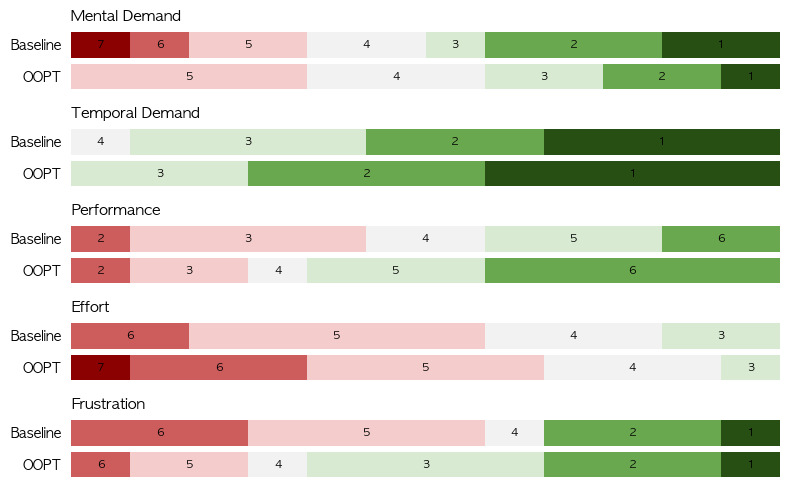

In [5]:
plot_likert_responses(TLX_likert_cols, "Task Load Index (TLX) Likert Responses")

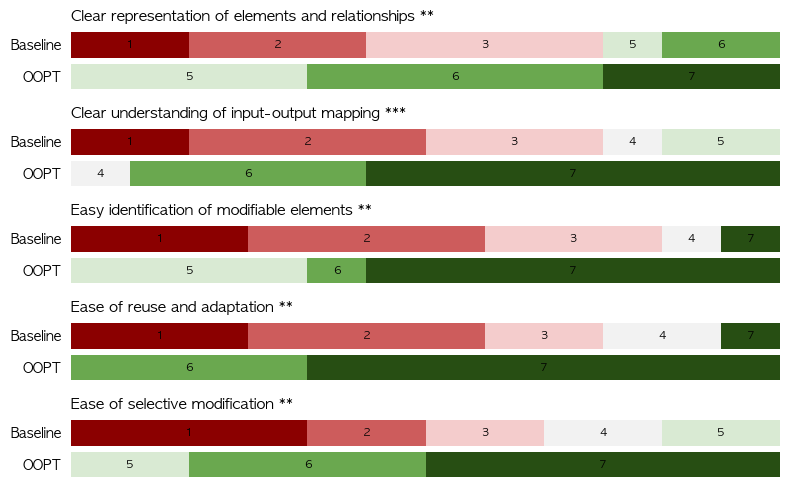

In [6]:
plot_likert_responses(Sys_likert_cols, "System specific features Likert Responses")

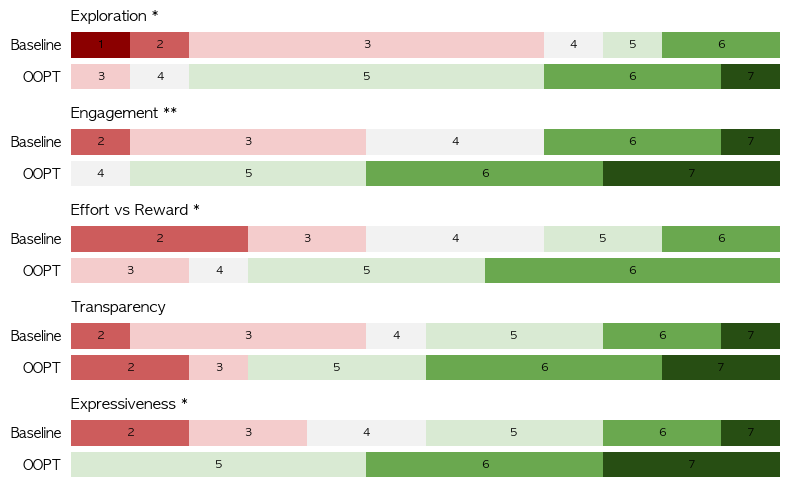

In [7]:
plot_likert_responses(CSI_likert_cols, "Creativity Support Index (CSI) Likert Responses")

In [8]:

def survey_boot_ci(likert_cols):
    reverse_items = {"mental_demand","temporal_demand","effort","frustration"}

    def orient_scores(s, name):
        v = pd.to_numeric(s, errors="coerce")
        return 8 - v if name in reverse_items else v

    X = df.copy()
    for c in likert_cols:
        X[c] = orient_scores(X[c], c)

    # 부트스트랩 CI
    def boot_ci(x, n=3000, alpha=0.05):
        x = pd.to_numeric(x, errors="coerce").dropna().values
        if len(x)==0: return (np.nan, np.nan)
        boots = np.random.choice(x, (n, len(x)), True).mean(axis=1)
        return np.percentile(boots, [100*alpha/2, 100*(1-alpha/2)])

    means = X.groupby("system_type")[likert_cols].mean().T
    cis = {sys: X[X.system_type==sys][likert_cols].apply(lambda col: boot_ci(col), axis=0)
        for sys in ["Baseline","OOPT"]}

    y = np.arange(len(likert_cols))
    plt.figure(figsize=(9, 0.6*len(likert_cols)))
    color_map = {"Baseline": "#1f77b4", "OOPT": "#ff7f0e"}
    for i,q in enumerate(likert_cols):
        m1, m2 = means.loc[q, "Baseline"], means.loc[q, "OOPT"]
        c1, c2 = cis["Baseline"][q], cis["OOPT"][q]
        # CI
        plt.plot(c1, [y[i]]*2, lw=4, solid_capstyle="round", color=color_map["Baseline"] + '4D')
        plt.plot(c2, [y[i]]*2, lw=4, solid_capstyle="round", color=color_map["OOPT"] + '4D')
        # mean 점
        plt.scatter([m1], [y[i]], s=36, zorder=3, color=color_map["Baseline"])
        plt.scatter([m2], [y[i]], s=36, zorder=3, color=color_map["OOPT"])
        # 덤벨 연결선
        # plt.plot([m1, m2], [y[i], y[i]], color="#666", lw=1)

    plt.yticks(y, likert_cols)
    plt.xlabel("Mean score (higher is better)")
    # legend: 색상과 시스템명 직접 표시, 차트 오른쪽 바깥에 위치
    import matplotlib.lines as mlines
    handles = [
        mlines.Line2D([], [], color=color_map["Baseline"], marker='o', linestyle='None', markersize=8, label='Baseline'),
        mlines.Line2D([], [], color=color_map["OOPT"], marker='o', linestyle='None', markersize=8, label='OOPT'),
    ]
    plt.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False)
    plt.xlim(1,7)
    plt.tight_layout(); plt.show()


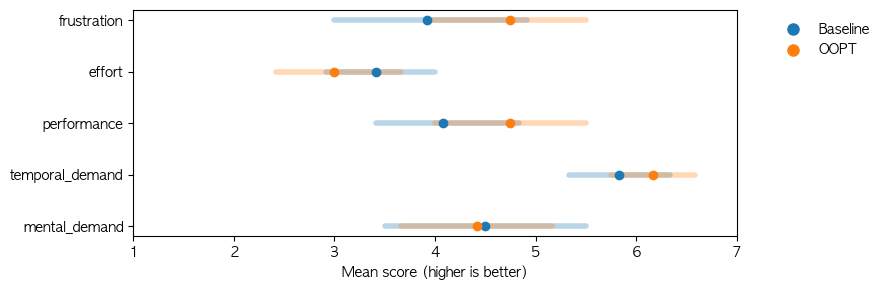

In [9]:
survey_boot_ci(TLX_likert_cols)

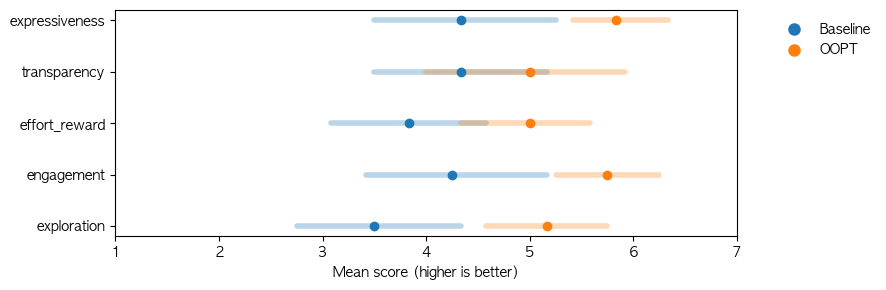

In [10]:
survey_boot_ci(CSI_likert_cols)

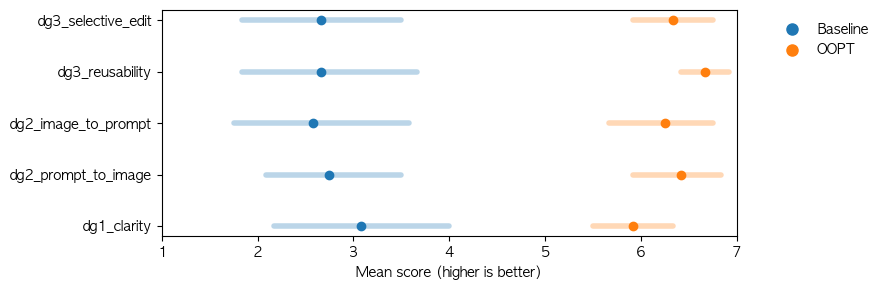

In [11]:
survey_boot_ci(Sys_likert_cols)

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.gridspec import GridSpec

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['font.size'] = 10

def _pvalue_for_question(df_q, sys_a="Baseline", sys_b="OOPT"):
    a = df_q.loc[df_q["system_type"]==sys_a, "response"].to_numpy()
    b = df_q.loc[df_q["system_type"]==sys_b, "response"].to_numpy()
    if a.size==0 or b.size==0:
        return np.nan
    try:
        import scipy.stats as st
        if "participant_id" in df_q.columns:
            pa = df_q[df_q["system_type"]==sys_a][["participant_id","response"]]
            pb = df_q[df_q["system_type"]==sys_b][["participant_id","response"]]
            merged = pa.merge(pb, on="participant_id", suffixes=("_a","_b"))
            if len(merged) >= 5:
                _, p = st.wilcoxon(merged["response_a"], merged["response_b"], zero_method="wilcox")
                return p
        _, p = st.mannwhitneyu(a, b, alternative="two-sided")
        return p
    except Exception:
        rng = np.random.default_rng(42)
        obs = np.mean(a) - np.mean(b)
        boots = []
        for _ in range(10000):
            aa = rng.choice(a, size=a.size, replace=True)
            bb = rng.choice(b, size=b.size, replace=True)
            boots.append(np.mean(aa) - np.mean(bb))
        boots = np.asarray(boots)
        p = (np.sum(np.abs(boots) >= np.abs(obs)) + 1) / (len(boots) + 1)
        return float(p)

def _stars(p):
    if not np.isfinite(p): return ""
    if p < 1e-3: return " ***"
    if p < 1e-2: return " **"
    if p < 5e-2: return " *"
    return ""

def plot_likert_counts(df, likert_cols, *,
                       question_labels,
                       reverse_items=("mental_demand","temporal_demand","effort","frustration"),
                       systems_order=("Baseline","OOPT"),
                       title="Likert Responses (Counts, Neutral-Centered, Global Scale)",
                       figsize=(8, None),      # (폭, 높이). 높이 None이면 자동(질문 수 기반)
                       title_offset=-0.12,       # 타이틀을 플롯 왼쪽 바깥으로 밀어내는 정도 (axes 좌표계)
                       hspace=0.2,
                       save_title=None
                       ):
    # 1) reverse 값 변환
    df_rev = df.copy()
    for col in reverse_items:
        if col in df_rev.columns:
            df_rev[col] = pd.to_numeric(df_rev[col], errors="coerce")
            df_rev[col] = (8 - df_rev[col]).clip(1,7)

    # 2) long
    long = (df_rev.melt(id_vars="system_type", value_vars=likert_cols,
                        var_name="question", value_name="response")
                  .assign(response=lambda d: pd.to_numeric(d["response"], errors="coerce"))
                  .dropna(subset=["response"]))
    long["response"] = long["response"].astype(int).clip(1,7)

    # 3) 시스템 순서
    systems_present = [s for s in systems_order if s in long["system_type"].unique()]
    if not systems_present:
        systems_present = list(long["system_type"].unique())
    sys_to_y = {sys:i for i,sys in enumerate(systems_present)}  # y=0,1,...

    # 4) count table
    idx = pd.MultiIndex.from_product(
        [systems_present, likert_cols, range(1,8)],
        names=["system_type","question","response"]
    )
    counts = (long.groupby(["system_type","question","response"]).size()
                .reindex(idx, fill_value=0)
                .rename("count").reset_index())

    # 5) global span
    global_span = 0
    global_span_left = 0
    global_span_right = 0
    for q in likert_cols:
        for sys in systems_present:
            row = counts[(counts["system_type"]==sys) & (counts["question"]==q)]
            c = {r: int(row.loc[row["response"]==r,"count"]) if not row.loc[row["response"]==r].empty else 0
                 for r in range(1,8)}
            span_left  = (c[1] + c[2] + c[3]) + c[4]/2
            span_right = (c[5] + c[6] + c[7]) + c[4]/2
            global_span = max(global_span, span_left, span_right)
            global_span_left = max(global_span_left, span_left)
            global_span_right = max(global_span_right, span_right)

    # 6) colors (1=red → 7=blue). RdBu를 쓰되, 1이 red가 되도록 설정
    base_colors = [plt.cm.RdBu(i) for i in np.linspace(0,1,7)]  # RdBu: red→blue

    # 7) Figure & GridSpec (✅ 1컬럼: 플롯만)
    n = len(likert_cols)
    if figsize[1] is None:
        fig_h = 0.8 * n
    else:
        fig_h = figsize[1]
    fig = plt.figure(figsize=(figsize[0], fig_h))
    gs = GridSpec(nrows=n, ncols=1, hspace=hspace)

    if title:
        fig.suptitle(title, y=0.995, fontsize=13, fontweight="bold")

    # 미리 p-values 계산
    pvals = {}
    for q in likert_cols:
        df_q = long[long["question"]==q][["system_type","response"] + (["participant_id"] if "participant_id" in long.columns else [])]
        pvals[q] = _pvalue_for_question(df_q, systems_present[0], systems_present[1]) if len(systems_present)>=2 else np.nan

    # 8) 각 row 그리기 (플롯만, ytick으로 시스템 라벨)
    for i, q in enumerate(likert_cols):
        ax = fig.add_subplot(gs[i, 0])

        # Title: 플롯 내부에서 왼쪽 바깥쪽으로 살짝
        title_txt = f"{question_labels.get(q, q.replace('_',' ').title())}{_stars(pvals.get(q, np.nan))}"
        ax.text(title_offset, 0.5, title_txt,
                transform=ax.transAxes, ha="right", va="center",
                fontsize=11, fontweight="bold")

        # Bars
        for sys, y in sys_to_y.items():
            row = counts[(counts["system_type"]==sys) & (counts["question"]==q)]
            c = {r: int(row.loc[row["response"]==r,"count"]) if not row.loc[row["response"]==r].empty else 0
                 for r in range(1,8)}

            # LEFT (1..3) – 양수 width, 정확한 left
            left_edge = -(c[1] + c[2] + c[3])- c[4]/2
            if c[1] > 0: ax.barh(y, c[1], left=left_edge, color=base_colors[0], height=0.6)
            left_edge += c[1]
            if c[2] > 0: ax.barh(y, c[2], left=left_edge, color=base_colors[1], height=0.6)
            left_edge += c[2]
            if c[3] > 0: ax.barh(y, c[3], left=left_edge, color=base_colors[2], height=0.6)

            # NEUTRAL (4) 가운데
            if c[4] > 0: ax.barh(y, c[4], left=-c[4]/2, color=base_colors[3], height=0.6)

            # RIGHT (5..7)
            right_left = c[4]/2
            if c[5] > 0: ax.barh(y, c[5], left=right_left, color=base_colors[4], height=0.6); right_left += c[5]
            if c[6] > 0: ax.barh(y, c[6], left=right_left, color=base_colors[5], height=0.6); right_left += c[6]
            if c[7] > 0: ax.barh(y, c[7], left=right_left, color=base_colors[6], height=0.6)

        # 축/스타일
        ax.axvline(0, color="grey", linestyle="--", lw=1, alpha=0.8)
        ax.axvline(-global_span_left, color="grey", linestyle="-", lw=1, alpha=0.8)
        ax.set_ylim(-0.5, len(systems_present)-0.5)
        ax.set_xlim(-global_span_left, global_span_right)      # ✅ 모든 row 동일 스케일
        ax.set_yticks(list(sys_to_y.values()))
        ax.set_yticklabels([])   # ✅ 짧은 ytick만 사용
        ax.tick_params(axis="x", bottom=False, labelbottom=False)
        ax.tick_params(axis="y", length=0)     # ✅ ytick 옆 작은 tick 막대도 제거
        # ax.yaxis.tick_right()
        
        # 시스템별 라벨 직접 그리기
        for sys, y in sys_to_y.items():
            ax.text(-0.03, y, sys,    # x좌표: 막대 오른쪽 여백 조금
                    va="center", ha="right",      # 세로 가운데, 왼쪽 정렬
                    fontsize=8, fontweight="bold",
                    transform=ax.get_yaxis_transform())  # y는 데이터좌표, x는 axis좌표
            
        for sp in ax.spines.values():
            sp.set_visible(False)
        ax.spines['left'].set_visible(False)   # ✅ 왼쪽 spine만 확실히 끔


    # 범례
    handles = [Patch(facecolor=plt.cm.RdBu(i), label=lab)
               for i, lab in zip(np.linspace(0,1,7), ["1 (Strongly Disagree)","2","3","4 (Neutral)","5","6","7 (Strongly Agree)"])]
    fig.legend(handles=handles, loc="lower center", ncol=7, frameon=False)

    plt.tight_layout(rect=[0, 0.06, 1, 0.99])
    if save_title:
        plt.savefig(save_title, dpi=300, bbox_inches="tight")

        print("Saved to ", save_title)
    plt.show()


/var/folders/yy/wmmdvn295kn5535yf3g57f2m0000gn/T/ipykernel_80610/2860321405.py:91: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  c = {r: int(row.loc[row["response"]==r,"count"]) if not row.loc[row["response"]==r].empty else 0
/var/folders/yy/wmmdvn295kn5535yf3g57f2m0000gn/T/ipykernel_80610/2860321405.py:133: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  c = {r: int(row.loc[row["response"]==r,"count"]) if not row.loc[row["response"]==r].empty else 0
/var/folders/yy/wmmdvn295kn5535yf3g57f2m0000gn/T/ipykernel_80610/2860321405.py:133: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  c = {r: int(row.loc[row["response"]==r,"count"]) if not row.loc[row["response"]==r].empty else 0
/var/folders/yy/wmmdvn295kn5535yf3g

Saved to  figure_0903/TLX_study1.pdf


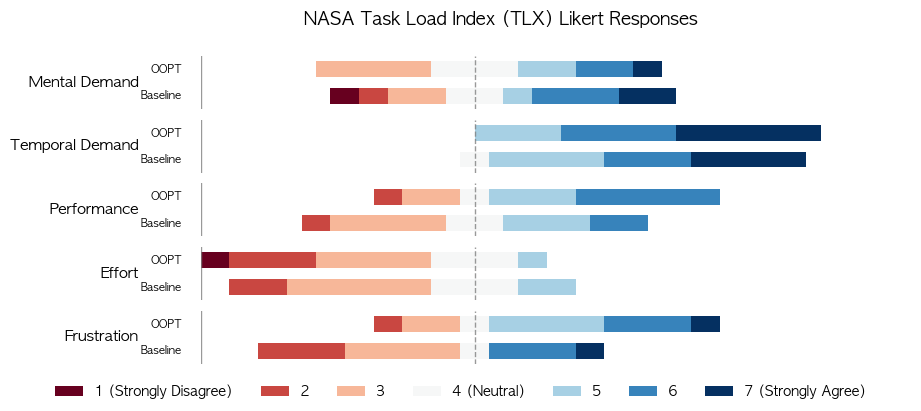

/var/folders/yy/wmmdvn295kn5535yf3g57f2m0000gn/T/ipykernel_80610/2860321405.py:91: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  c = {r: int(row.loc[row["response"]==r,"count"]) if not row.loc[row["response"]==r].empty else 0
/var/folders/yy/wmmdvn295kn5535yf3g57f2m0000gn/T/ipykernel_80610/2860321405.py:133: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  c = {r: int(row.loc[row["response"]==r,"count"]) if not row.loc[row["response"]==r].empty else 0
/var/folders/yy/wmmdvn295kn5535yf3g57f2m0000gn/T/ipykernel_80610/2860321405.py:133: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  c = {r: int(row.loc[row["response"]==r,"count"]) if not row.loc[row["response"]==r].empty else 0
/var/folders/yy/wmmdvn295kn5535yf3g

Saved to  figure_0903/Sys_study1.pdf


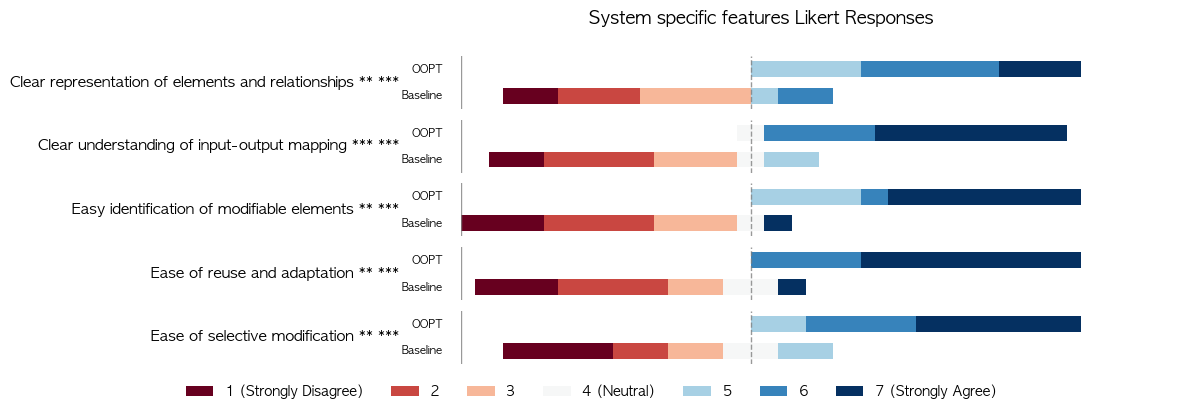

/var/folders/yy/wmmdvn295kn5535yf3g57f2m0000gn/T/ipykernel_80610/2860321405.py:91: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  c = {r: int(row.loc[row["response"]==r,"count"]) if not row.loc[row["response"]==r].empty else 0
/var/folders/yy/wmmdvn295kn5535yf3g57f2m0000gn/T/ipykernel_80610/2860321405.py:133: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  c = {r: int(row.loc[row["response"]==r,"count"]) if not row.loc[row["response"]==r].empty else 0
/var/folders/yy/wmmdvn295kn5535yf3g57f2m0000gn/T/ipykernel_80610/2860321405.py:133: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  c = {r: int(row.loc[row["response"]==r,"count"]) if not row.loc[row["response"]==r].empty else 0
/var/folders/yy/wmmdvn295kn5535yf3g

Saved to  figure_0903/CSI_study1.pdf


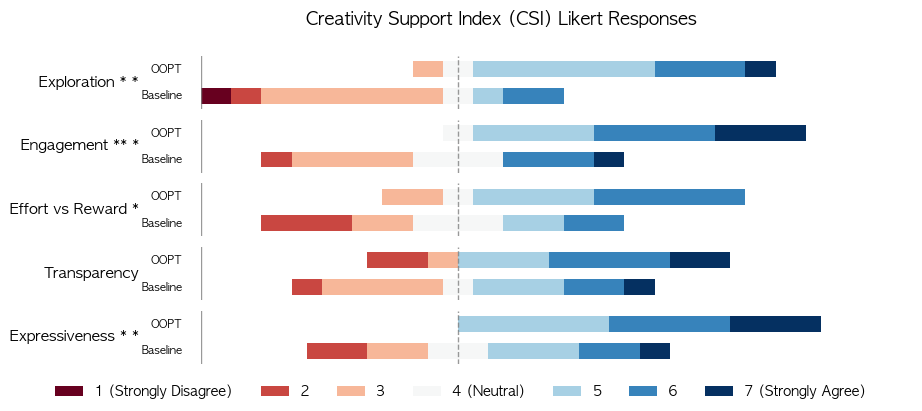

In [13]:
plot_likert_counts(
    df, TLX_likert_cols,
    question_labels=question_labels,
    figsize=(8, None),      # 폭 12 고정, 높이는 질문 수에 따라 자동
    title_offset=-0.1,      # 제목을 더 왼쪽으로 빼고 싶으면 -0.2, 덜 빼고 싶으면 -0.08 등으로 조정
    title="NASA Task Load Index (TLX) Likert Responses",
        save_title="figure_0903/TLX_study1.pdf"

)
plot_likert_counts(
    df, Sys_likert_cols,
    question_labels=question_labels,
    figsize=(8, None),      # 폭 12 고정, 높이는 질문 수에 따라 자동
    title_offset=-0.1,      # 제목을 더 왼쪽으로 빼고 싶으면 -0.2, 덜 빼고 싶으면 -0.08 등으로 조정
    title="System specific features Likert Responses",
    save_title="figure_0903/Sys_study1.pdf"
)
plot_likert_counts(
    df, CSI_likert_cols,
    question_labels=question_labels,
    figsize=(8, None),      # 폭 12 고정, 높이는 질문 수에 따라 자동
    title_offset=-0.1,      # 제목을 더 왼쪽으로 빼고 싶으면 -0.2, 덜 빼고 싶으면 -0.08 등으로 조정
    title="Creativity Support Index (CSI) Likert Responses",
    save_title="figure_0903/CSI_study1.pdf"
)


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.lines as mlines

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['font.size'] = 10

REVERSE_ITEMS = {"mental_demand","temporal_demand","effort","frustration"}

def boot_ci(x, n=3000, alpha=0.05, seed=42):
    rng = np.random.default_rng(seed)
    x = pd.to_numeric(x, errors="coerce").dropna().values
    if len(x) == 0:
        return (np.nan, np.nan)
    boots = rng.choice(x, (n, len(x)), True).mean(axis=1)
    lo, hi = np.percentile(boots, [100*alpha/2, 100*(1-alpha/2)])
    return lo, hi

def _prepare_long(df, likert_cols):
    long = df.melt(id_vars="system_type", value_vars=likert_cols,
                   var_name="question", value_name="response")
    long["response"] = pd.to_numeric(long["response"], errors="coerce")
    long = long[long["response"].between(1, 7, inclusive="both")]
    return long

def plot_likert_grid_counts(df, likert_cols, question_labels, title="Likert Responses (Counts)"):
    long = _prepare_long(df, likert_cols)
    n_rows = len(likert_cols)

    fig, axes = plt.subplots(n_rows, 2, figsize=(7, n_rows*0.4), sharex=False)
    if n_rows == 1:
        axes = np.array([axes])

    # Likert 색상: RdBu 7단계
    cmap = cm.get_cmap("RdBu", 7)
    colors = [cmap(i) for i in range(7)]

    ci_color = {"Baseline": "#808080", "OOPT": "#0072b2"}
    ci_alpha_hex = "4D"
    y_center = 0.5
    y_jitter = {"OOPT": +0.06, "Baseline": -0.06}

    for r, q in enumerate(likert_cols):
        # qlabel = question_labels.get(q, q)
        if q in REVERSE_ITEMS:
            row_label = f"{question_labels.get(q,q)} ↓"
        else:
            row_label = question_labels.get(q,q)

        # --- 1열: OOPT 누적 (명) ---
        ax1 = axes[r, 0]
        sub = long[(long["system_type"]=="Baseline") & (long["question"]==q)]
        counts = sub["response"].value_counts().sort_index()
        left = 0
        for i in range(1, 8):
            val = int(counts.get(i, 0))
            ax1.barh([0], [val], left=left, color=colors[i-1],
                     edgecolor='none', linewidth=0, height=0.9)
            left += val
        if r == 0: ax1.set_title("Baseline", fontweight="bold")
        ax1.set_xlim(0, 12)   # 총 응답자 수
        ax1.set_yticks([])
        if r == n_rows-1: ax1.set_xlabel('Number of Participants')
        else: ax1.set_xticklabels([])
        # ax1.set_ylabel(qlabel, rotation=0, ha="right", va="center")
        ax1.set_ylabel(row_label, rotation=0, ha="right", va="center", labelpad=15)

        ax1.yaxis.set_label_coords(-0.02, 0.5)
        for spine in ax1.spines.values(): spine.set_visible(False)
        ax1.tick_params(left=False, bottom=False)

        # --- 2열: Baseline 누적 (명) ---
        ax2 = axes[r, 1]
        sub = long[(long["system_type"]=="OOPT") & (long["question"]==q)]
        counts = sub["response"].value_counts().sort_index()
        left = 0
        for i in range(1, 8):
            val = int(counts.get(i, 0))
            ax2.barh([0], [val], left=left, color=colors[i-1],
                     edgecolor='none', linewidth=0, height=0.9)
            left += val
        if r == 0: ax2.set_title("PromptBlock", fontweight="bold")
        ax2.set_xlim(0, 12)
        ax2.set_yticks([])
        if r == n_rows-1: ax2.set_xlabel('Number of Participants')
        else: ax2.set_xticklabels([])
        for spine in ax2.spines.values(): spine.set_visible(False)
        ax2.tick_params(left=False, bottom=False)

        # # --- 3열: Mean+CI (배경+grid, 여긴 그대로) ---
        # ax3 = axes[r, 2]
        # # ax3.set_facecolor("#ffffff")
        # ax3.grid(axis="x", linestyle="--", alpha=0.4)

        # def orient(series): return 8 - series if q in REVERSE_ITEMS else series
        # vals_oopt = orient(long[(long["system_type"]=="OOPT") & (long["question"]==q)]["response"])
        # vals_base = orient(long[(long["system_type"]=="Baseline") & (long["question"]==q)]["response"])
        # m_oopt = np.nanmean(vals_oopt); lo_oopt, hi_oopt = boot_ci(vals_oopt)
        # m_base = np.nanmean(vals_base); lo_base, hi_base = boot_ci(vals_base)

        # ax3.plot([lo_oopt, hi_oopt], [y_center, y_center], lw=4, solid_capstyle="round",
        #          color=ci_color["OOPT"] + ci_alpha_hex, zorder=2)
        # ax3.plot([lo_base, hi_base], [y_center, y_center], lw=4, solid_capstyle="round",
        #          color=ci_color["Baseline"] + ci
        # _alpha_hex, zorder=2)
        # ax3.scatter([m_oopt], [y_center + y_jitter["OOPT"]], s=36, color=ci_color["OOPT"], zorder=3)
        # ax3.scatter([m_base], [y_center + y_jitter["Baseline"]], s=36, color=ci_color["Baseline"], zorder=3)


        # if r == 0:
        #     ax3.set_title("Mean ± bootstrapped CI", fontweight="bold")
        #     handles = [
        #         mlines.Line2D([], [], color=ci_color["OOPT"], marker='o', linestyle='None',
        #                       markersize=6, label='OOPT'),
        #         mlines.Line2D([], [], color=ci_color["Baseline"], marker='o', linestyle='None',
        #                       markersize=6, label='Baseline'),
        #     ]
        #     ax3.legend(handles=handles, loc="upper right", frameon=False)

        # ax3.set_xlim(1, 7); ax3.set_ylim(0, 1); ax3.set_yticks([])
        # if r == n_rows-1: ax3.set_xlabel("Mean score")
        # else: ax3.set_xticklabels([])
        # for spine in ax3.spines.values(): spine.set_visible(False)
        # # for spine in ax3.spines.values():
        # #     spine.set_color("#a0a0a0",)   # 연한 회색 테두리
        # ax3.set_facecolor("#f2f2f2")   # 아주 연한 회색 배경 박스

        # # for spine in ax3.spines.values(): spine.set_visible(False)
        # ax3.tick_params(left=False, bottom=False)
    # fig.subplots_adjust(left=0.35, hspace=0.01, wspace=0.05)  # left=0.35 고정

    # Likert scale legendㅍ
    legend_handles = [mlines.Line2D([], [], color=colors[i], marker='s', linestyle='None',
                                    markersize=8, label=str(i+1)) for i in range(7)]
    fig.legend(handles=legend_handles, title="Likert scale",
               bbox_to_anchor=(0.5, -0.02), loc="upper center", ncol=7, frameon=False)

    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.02)
    fig.text(
        1, -0.02,  # x=가운데, y=figure 아래쪽 (음수면 더 내려감)
        "↓ : lower is better   \n    * : p < 0.05  ** : p < 0.01  *** : p < 0.001",
        ha="right", va="top", fontsize=10, color="black"
    )
    fig.text(
        1, -0.02,  # x=가운데, y=figure 아래쪽 (음수면 더 내려감)
        "System specific features",
        ha="right", va="top", fontsize=12, color="black", fontweight="bold"
    )

    fig.text(
            1, 0,  # x=가운데, y=figure 아래쪽 (음수면 더 내려감)
            "NASA Task Load Index (NASA-TLX)",
            ha="right", va="top", fontsize=12, color="black", fontweight="bold"
        )
    fig.text(
            1, 0.02,  # x=가운데, y=figure 아래쪽 (음수면 더 내려감)
            "Creativity Support Index (CSI)",
            ha="right", va="top", fontsize=12, color="black", fontweight="bold"
        )
    # plt.tight_layout()
    plt.subplots_adjust(hspace=0.2, wspace=0.1)
    
    plt.savefig(f"figure_0903/{title.replace(' ','_')}.svg", dpi=300, bbox_inches="tight")
    plt.show()


/var/folders/yy/wmmdvn295kn5535yf3g57f2m0000gn/T/ipykernel_80610/2247282566.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("RdBu", 7)


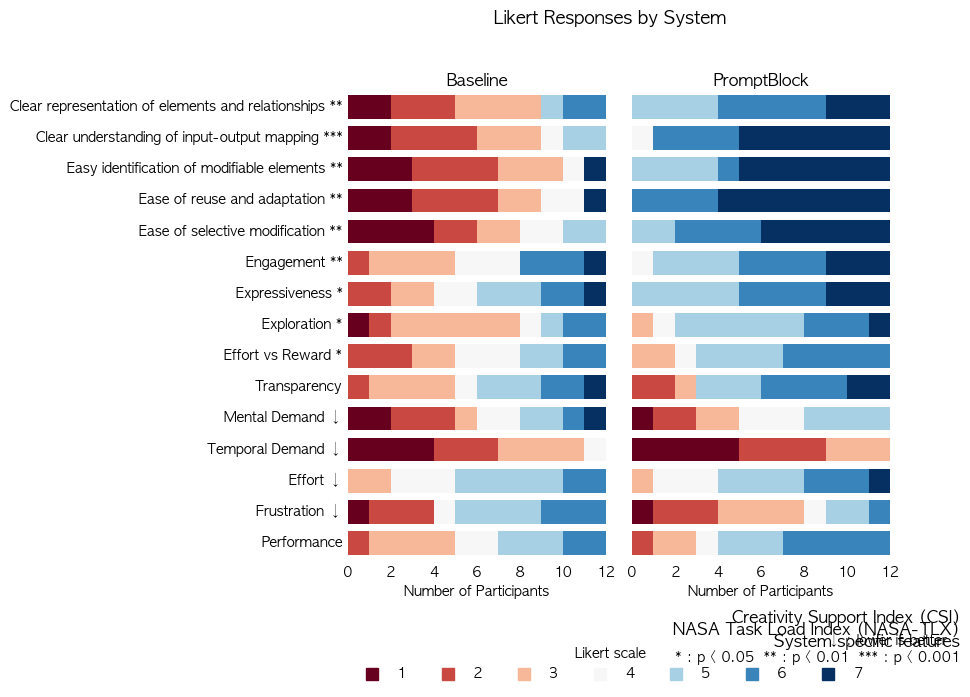

In [15]:
plot_likert_grid_counts(df, likert_cols, question_labels, title="Likert Responses by System")

In [16]:
import numpy as np
import pandas as pd
from scipy import stats

def fmt_p(p):
    if pd.isna(p): return "–"
    if p < 0.001: return "<0.001"
    if p < 0.01:  return "<0.01"
    if p < 0.05:  return "<0.05"
    return f"{p:.2f}"   # not significant → 그대로 숫자

def _orient(series, reverse=False):
    s = pd.to_numeric(series, errors="coerce")
    s = s[s.between(1,7, inclusive="both")]
    return (8 - s) if reverse else s

def survey_stats_report(df, likert_cols, reverse_items=REVERSE_ITEMS, id_col="participant", decimals=2):
    rows = []
    for q in likert_cols:
        # wide 형식으로 정리 (Baseline vs OOPT 쌍)
        wide = df.pivot_table(index=id_col, columns="system_type", values=q, aggfunc="first")
        base = _orient(wide.get("Baseline"), reverse=(q in reverse_items))
        oopt = _orient(wide.get("OOPT"), reverse=(q in reverse_items))
        paired = pd.DataFrame({"Baseline": base, "OOPT": oopt}).dropna()

        # 기술통계
        m_b, sd_b = np.mean(paired["Baseline"]), np.std(paired["Baseline"], ddof=1)
        m_o, sd_o = np.mean(paired["OOPT"]), np.std(paired["OOPT"], ddof=1)

        # Wilcoxon signed-rank test
        p = np.nan
        if len(paired) > 0:
            try:
                diff = (paired["OOPT"] - paired["Baseline"]).values
                if np.allclose(diff, 0, equal_nan=False):
                    p = 1.0
                else:
                    _, p = stats.wilcoxon(paired["Baseline"], paired["OOPT"], zero_method="wilcox")
            except ValueError:
                p = np.nan
        print(q, p)
        # 논문 보고용 포맷 (Baseline: M=.., SD=../ OOPT: M=.., SD=../ p < ..)
        report = (
            f"(Baseline: M={m_b:.{decimals}f}, SD={sd_b:.{decimals}f}/ "
            f"OOPT: M={m_o:.{decimals}f}, SD={sd_o:.{decimals}f}/ p {fmt_p(p)})"
        )

        rows.append({"question": q, "report": report})

    return pd.DataFrame(rows)

# 사용 예시
likert_cols = [
    "mental_demand","temporal_demand","performance","effort","frustration",
    "exploration","engagement","effort_reward","transparency","expressiveness",
    "dg1_clarity","dg2_prompt_to_image","dg2_image_to_prompt",
    "dg3_reusability","dg3_selective_edit"
]
df = pd.read_csv("result/survey/survey_responses.csv")

table_df = survey_stats_report(df, likert_cols, id_col="user_id")
print(table_df.to_string(index=False))


mental_demand 0.9141283452014198
temporal_demand 0.15729920705028516
performance 0.19521006938475483
effort 0.28504940740261275
frustration 0.06464003076463333
exploration 0.030295168108521862
engagement 0.009774339062913267
effort_reward 0.03222230445704992
transparency 0.28072258109188986
expressiveness 0.00853536844623526
dg1_clarity 0.007109552693052261
dg2_prompt_to_image 0.00048828125
dg2_image_to_prompt 0.00311609469471783
dg3_reusability 0.003146136452135306
dg3_selective_edit 0.0029830385475470103
           question                                                       report
      mental_demand   (Baseline: M=4.50, SD=1.98/ OOPT: M=4.42, SD=1.38/ p 0.91)
    temporal_demand   (Baseline: M=5.83, SD=1.03/ OOPT: M=6.17, SD=0.83/ p 0.16)
        performance   (Baseline: M=4.08, SD=1.31/ OOPT: M=4.75, SD=1.42/ p 0.20)
             effort   (Baseline: M=3.42, SD=1.00/ OOPT: M=3.00, SD=1.13/ p 0.29)
        frustration   (Baseline: M=3.92, SD=1.83/ OOPT: M=4.75, SD=1.48/ p 0.06)
  

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Sample size too small for normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Sample size too small for normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/Library/Frameworks/Py

In [17]:
import numpy as np
import pandas as pd
from scipy import stats

REVERSE_ITEMS = {"mental_demand","temporal_demand","effort","frustration"}

def fmt_p(p):
    if pd.isna(p): return "–"
    if p < 0.001: return "<0.001"
    if p < 0.01:  return "<0.01"
    if p < 0.05:  return "<0.05"
    return f"{p:.2f}"

def _orient(series, reverse=False):
    s = pd.to_numeric(series, errors="coerce")
    s = s[s.between(1,7, inclusive="both")]
    return (8 - s) if reverse else s

def _wilcoxon_z_from_diff(diff):
    """
    diff: array-like of OOPT - Baseline (zeros already removed)
    Returns: z, W_plus, W_minus, n (with tie-variance & continuity correction)
    """
    diff = np.asarray(diff, dtype=float)
    # remove zeros if any remain
    diff = diff[diff != 0]
    n = diff.size
    if n == 0:
        return np.nan, np.nan, np.nan, 0

    abs_diff = np.abs(diff)
    # average ranks for ties, like SPSS
    ranks = stats.rankdata(abs_diff, method="average")

    W_plus = np.sum(ranks[diff > 0])
    W_minus = np.sum(ranks[diff < 0])
    T = min(W_plus, W_minus)

    # mean of T under H0
    mu = n * (n + 1) / 4.0

    # variance with tie correction
    # tie counts from absolute differences
    _, counts = np.unique(abs_diff, return_counts=True)
    tie_term = np.sum(counts * (counts + 1) * (2 * counts + 1))
    var = (n * (n + 1) * (2 * n + 1) - tie_term) / 24.0
    if var <= 0:
        return np.nan, W_plus, W_minus, n

    sigma = np.sqrt(var)

    # continuity correction (±0.5 toward the mean)
    cc = 0.5 * np.sign(T - mu)
    z = (T - mu - cc) / sigma

    return z, W_plus, W_minus, n

def survey_stats_report(df, likert_cols, reverse_items=REVERSE_ITEMS, id_col="participant", decimals=2, include_effect_size=True):
    rows = []
    for q in likert_cols:
        wide = df.pivot_table(index=id_col, columns="system_type", values=q, aggfunc="first")
        base = _orient(wide.get("Baseline"), reverse=(q in reverse_items))
        oopt = _orient(wide.get("OOPT"), reverse=(q in reverse_items))
        paired = pd.DataFrame({"Baseline": base, "OOPT": oopt}).dropna()

        # 기술통계
        m_b, sd_b = np.mean(paired["Baseline"]), np.std(paired["Baseline"], ddof=1)
        m_o, sd_o = np.mean(paired["OOPT"]), np.std(paired["OOPT"], ddof=1)

        # Wilcoxon p-value (SciPy), Z는 수식으로 계산
        p = np.nan
        z = np.nan
        r = np.nan
        if len(paired) > 0:
            try:
                diff = (paired["OOPT"] - paired["Baseline"]).values
                if np.allclose(diff, 0, equal_nan=False):
                    p = 1.0
                    z = 0.0
                    r = 0.0
                else:
                    # SciPy p-value (동점/표본크기에 따라 exact/approx 내부 결정)
                    _, p = stats.wilcoxon(paired["Baseline"], paired["OOPT"], zero_method="wilcox")
                    # Z (tie 보정 + 연속성 보정)
                    z, Wp, Wm, n = _wilcoxon_z_from_diff(diff)
                    if include_effect_size and n > 0 and not np.isnan(z):
                        # APA에서 자주 쓰는 효과크기: r = |Z| / sqrt(N)
                        r = abs(z) / np.sqrt(n)
            except ValueError:
                p = np.nan
                z = np.nan
                r = np.nan

        # 콘솔 확인용
        print(q, "p=", p, "z=", z)

        # 보고용 문장 (Baseline: ... / OOPT: ... / Z=.., p .. [, r=..])
        z_txt = "–" if pd.isna(z) else f"{z:.2f}"
        if include_effect_size and not pd.isna(r):
            eff_txt = f", r={r:.2f}"
        else:
            eff_txt = ""

        report = (
            f"(Baseline: M={m_b:.{decimals}f}, SD={sd_b:.{decimals}f}; "
            f"\systemname: M={m_o:.{decimals}f}, SD={sd_o:.{decimals}f}; "
            f"Z={z_txt}, p {fmt_p(p)})"
        )

        rows.append({"question": q, "report": report})

    return pd.DataFrame(rows)

# 사용 예시
likert_cols = [
    "mental_demand","temporal_demand","performance","effort","frustration",
    "exploration","engagement","effort_reward","transparency","expressiveness",
    "dg1_clarity","dg2_prompt_to_image","dg2_image_to_prompt",
    "dg3_reusability","dg3_selective_edit"
]
df = pd.read_csv("result/survey/survey_responses.csv")
table_df = survey_stats_report(df, likert_cols, id_col="user_id")
print(table_df.to_string(index=False))


mental_demand p= 0.9141283452014198 z= 0.0
temporal_demand p= 0.15729920705028516 z= -1.8371173070873836
performance p= 0.19521006938475483 z= -1.3609151450969825
effort p= 0.28504940740261275 z= -1.9170289512680814
frustration p= 0.06464003076463333 z= -1.952172023607576
exploration p= 0.030295168108521862 z= -2.296100253106348
engagement p= 0.009774339062913267 z= -2.7391832724372422
effort_reward p= 0.03222230445704992 z= -2.3735633163877066
transparency p= 0.28072258109188986 z= -1.0814761408717504
expressiveness p= 0.00853536844623526 z= -2.7650063180466553
dg1_clarity p= 0.007109552693052261 z= -2.799652957093422
dg2_prompt_to_image p= 0.00048828125 z= -3.248048962693903
dg2_image_to_prompt p= 0.00311609469471783 z= -3.04724700110022
dg3_reusability p= 0.003146136452135306 z= -3.03064062678102
dg3_selective_edit p= 0.0029830385475470103 z= -3.1200998447925756
           question                                                                       report
      mental_demand    (B

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Sample size too small for normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Sample size too small for normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/Library/Frameworks/Py

In [18]:
import numpy as np
import pandas as pd
from scipy import stats

REVERSE_ITEMS = {"mental_demand","temporal_demand","effort","frustration"}

def fmt_p(p):
    if pd.isna(p): return "–"
    if p < 0.001: return "<0.001"
    if p < 0.01:  return "<0.01"
    if p < 0.05:  return "<0.05"
    return f"{p:.3f}"

def _orient(series, reverse=False):
    s = pd.to_numeric(series, errors="coerce")
    s = s[s.between(1,7, inclusive="both")]
    return (8 - s) if reverse else s

def _wilcoxon_z_from_diff(diff):
    """
    diff: array-like of OOPT - Baseline (zeros already removed)
    Returns: z, W_plus, W_minus, n (with tie-variance & continuity correction)
    
    주요 수정사항:
    1. W_plus를 기준으로 z값 계산 (방향성 유지)
    2. Tie correction 개선
    3. 연속성 보정 개선
    """
    diff = np.asarray(diff, dtype=float)
    # remove zeros if any remain
    diff = diff[diff != 0]
    n = diff.size
    if n == 0:
        return np.nan, np.nan, np.nan, 0

    abs_diff = np.abs(diff)
    # average ranks for ties, like SPSS
    ranks = stats.rankdata(abs_diff, method="average")

    W_plus = np.sum(ranks[diff > 0])
    W_minus = np.sum(ranks[diff < 0])
    
    # 기댓값 (W+의 기댓값)
    mu = n * (n + 1) / 4.0

    # variance with tie correction
    # tie counts from absolute differences
    unique_vals, counts = np.unique(abs_diff, return_counts=True)
    tie_correction = np.sum(counts * (counts - 1) * (counts + 1)) / 12.0
    var = (n * (n + 1) * (2 * n + 1) / 24.0) - tie_correction
    
    if var <= 0:
        return np.nan, W_plus, W_minus, n

    sigma = np.sqrt(var)

    # W_plus를 사용한 z값 계산 (방향성 유지)
    # 연속성 보정: W_plus가 기댓값보다 크면 -0.5, 작으면 +0.5
    if W_plus > mu:
        cc = -0.5
    elif W_plus < mu:
        cc = 0.5
    else:
        cc = 0.0
    
    z = (W_plus - mu + cc) / sigma

    return z, W_plus, W_minus, n

def survey_stats_report(df, likert_cols, reverse_items=REVERSE_ITEMS, id_col="participant", decimals=2, include_effect_size=True):
    """
    주요 개선사항:
    1. z값의 방향성이 실제 차이 방향과 일치
    2. 더 정확한 tie correction
    3. 효과크기 계산 개선
    4. 에러 처리 강화
    """
    rows = []
    for q in likert_cols:
        try:
            wide = df.pivot_table(index=id_col, columns="system_type", values=q, aggfunc="first")
            base = _orient(wide.get("Baseline"), reverse=(q in reverse_items))
            oopt = _orient(wide.get("OOPT"), reverse=(q in reverse_items))
            paired = pd.DataFrame({"Baseline": base, "OOPT": oopt}).dropna()

            if len(paired) == 0:
                print(f"경고: {q}에 대한 유효한 데이터가 없습니다.")
                continue

            # 기술통계
            m_b, sd_b = np.mean(paired["Baseline"]), np.std(paired["Baseline"], ddof=1)
            m_o, sd_o = np.mean(paired["OOPT"]), np.std(paired["OOPT"], ddof=1)
            mean_diff = m_o - m_b

            # Wilcoxon 검정
            p = np.nan
            z = np.nan
            r = np.nan
            
            diff = (paired["OOPT"] - paired["Baseline"]).values
            
            # 모든 차이가 0인 경우
            if np.all(diff == 0):
                p = 1.0
                z = 0.0
                r = 0.0
            else:
                # SciPy p-value
                try:
                    _, p = stats.wilcoxon(paired["Baseline"], paired["OOPT"], 
                                        zero_method="wilcox", alternative="two-sided")
                except ValueError as e:
                    print(f"경고: {q}에서 wilcoxon 검정 실패: {e}")
                    p = np.nan
                
                # 우리의 z값 계산
                z, Wp, Wm, n = _wilcoxon_z_from_diff(diff)
                
                # 효과크기 계산
                if include_effect_size and n > 0 and not np.isnan(z):
                    r = abs(z) / np.sqrt(n)

            # 디버깅 정보
            print(f"{q}: n={len(paired)}, mean_diff={mean_diff:.3f}, z={z:.3f}, p={p:.4f}")
            
            # z값과 평균 차이의 방향성 확인
            if not np.isnan(z) and not np.isnan(mean_diff):
                direction_match = (z > 0 and mean_diff > 0) or (z < 0 and mean_diff < 0) or (z == 0 and mean_diff == 0)
                if not direction_match:
                    print(f"  주의: {q}에서 z값({z:.3f})과 평균차이({mean_diff:.3f})의 방향이 다릅니다.")

            # 보고용 텍스트 생성
            z_txt = "–" if pd.isna(z) else f"{z:.2f}"
            if include_effect_size and not pd.isna(r):
                eff_txt = f", r={r:.2f}"
            else:
                eff_txt = ""

            report = (
                f"Baseline: M={m_b:.{decimals}f}, SD={sd_b:.{decimals}f}; "
                f"OOPT: M={m_o:.{decimals}f}, SD={sd_o:.{decimals}f}; "
                f"Z={z_txt}, p={fmt_p(p)}{eff_txt}"
            )

            rows.append({
                "question": q, 
                "report": report,
                "mean_baseline": m_b,
                "mean_oopt": m_o,
                "mean_diff": mean_diff,
                "z_value": z,
                "p_value": p,
                "effect_size": r,
                "n_pairs": len(paired)
            })

        except Exception as e:
            print(f"오류: {q} 처리 중 문제 발생: {e}")
            continue

    return pd.DataFrame(rows)

# 추가: 간단한 검증 함수
def validate_wilcoxon_calculation(baseline_vals, oopt_vals, question_name="test"):
    """
    Wilcoxon 계산 결과를 검증하는 함수
    """
    print(f"\n=== {question_name} 검증 ===")
    
    # 차이 계산
    diff = oopt_vals - baseline_vals
    non_zero_diff = diff[diff != 0]
    
    print(f"전체 참가자 수: {len(diff)}")
    print(f"유효 차이 수 (0 제외): {len(non_zero_diff)}")
    print(f"평균 차이 (OOPT - Baseline): {np.mean(diff):.4f}")
    
    if len(non_zero_diff) > 0:
        # 수동 계산
        abs_diff = np.abs(non_zero_diff)
        ranks = stats.rankdata(abs_diff, method="average")
        W_plus = np.sum(ranks[non_zero_diff > 0])
        W_minus = np.sum(ranks[non_zero_diff < 0])
        
        print(f"W+ (양수 차이 순위합): {W_plus}")
        print(f"W- (음수 차이 순위합): {W_minus}")
        print(f"양수 차이 개수: {np.sum(non_zero_diff > 0)}")
        print(f"음수 차이 개수: {np.sum(non_zero_diff < 0)}")
        
        # z값 계산
        z, _, _, n = _wilcoxon_z_from_diff(diff)
        print(f"계산된 z값: {z:.4f}")
        
        # scipy 결과와 비교
        try:
            _, p_scipy = stats.wilcoxon(baseline_vals, oopt_vals, zero_method="wilcox")
            print(f"scipy p값: {p_scipy:.4f}")
        except:
            print("scipy 계산 실패")

# 사용 예시
if __name__ == "__main__":
    # 테스트용 더미 데이터 생성
    np.random.seed(42)
    n_participants = 20
    
    test_data = []
    for i in range(n_participants):
        for system in ["Baseline", "OOPT"]:
            test_data.append({
                "user_id": f"P{i+1}",
                "system_type": system,
                "mental_demand": np.random.randint(1, 8),
                "performance": np.random.randint(1, 8),
                "engagement": np.random.randint(1, 8)
            })
    
    df_test = pd.DataFrame(test_data)
    
    # 실제 데이터 로드 (파일이 있는 경우)
    try:
        df = pd.read_csv("result/survey/survey_responses.csv")
        print("실제 데이터 로드 성공")
    except FileNotFoundError:
        print("실제 데이터 파일을 찾을 수 없어 테스트 데이터 사용")
        df = df_test
    
    # 분석 실행
    # likert_cols = ["mental_demand", "performance", "engagement"]
    
    if "user_id" in df.columns:
        id_col = "user_id"
    elif "participant" in df.columns:
        id_col = "participant"
    else:
        print("경고: ID 컬럼을 찾을 수 없습니다. 첫 번째 컬럼을 사용합니다.")
        id_col = df.columns[0]
    
    table_df = survey_stats_report(df, likert_cols, id_col=id_col)
    
    print("\n=== 최종 결과 ===")
    print(table_df[["question", "report"]].to_string(index=False))
    
    # 상세 정보도 출력
    if len(table_df) > 0:
        print("\n=== 상세 통계 ===")
        for _, row in table_df.iterrows():
            q = row["question"]
            print(f"{q}:")
            print(f"  평균 차이: {row['mean_diff']:.3f}")
            print(f"  Z값: {row['z_value']:.3f}")
            print(f"  p값: {row['p_value']:.4f}")
            print(f"  효과크기 r: {row['effect_size']:.3f}")
            print(f"  표본 수: {row['n_pairs']}")

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Sample size too small for normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Sample size too small for normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/Library/Frameworks/Py

실제 데이터 로드 성공
mental_demand: n=12, mean_diff=-0.083, z=0.000, p=0.9141
  주의: mental_demand에서 z값(0.000)과 평균차이(-0.083)의 방향이 다릅니다.
temporal_demand: n=12, mean_diff=0.333, z=1.521, p=0.1573
performance: n=12, mean_diff=0.667, z=1.311, p=0.1952
effort: n=12, mean_diff=-0.417, z=-1.583, p=0.2850
frustration: n=12, mean_diff=0.833, z=1.863, p=0.0646
exploration: n=12, mean_diff=1.667, z=2.226, p=0.0303
engagement: n=12, mean_diff=1.500, z=2.646, p=0.0098
effort_reward: n=12, mean_diff=1.167, z=2.268, p=0.0322
transparency: n=12, mean_diff=0.667, z=1.053, p=0.2807
expressiveness: n=12, mean_diff=1.500, z=2.676, p=0.0085
dg1_clarity: n=12, mean_diff=2.833, z=2.713, p=0.0071
dg2_prompt_to_image: n=12, mean_diff=3.667, z=3.170, p=0.0005
dg2_image_to_prompt: n=12, mean_diff=3.667, z=2.979, p=0.0031
dg3_reusability: n=12, mean_diff=4.000, z=2.967, p=0.0031
dg3_selective_edit: n=12, mean_diff=3.667, z=3.037, p=0.0030

=== 최종 결과 ===
           question                                                  

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Sample size too small for normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_f